In [41]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from typing import TypedDict, List, Dict
from dotenv import load_dotenv
load_dotenv()
from logger import CustomLogger
logger = CustomLogger().get_logger(__name__)
import io
import contextlib
from langgraph.types import Command

In [62]:
from typing import TypedDict, Optional, Dict, List
from pydantic import BaseModel, Field, constr
import json, traceback

class GeneratorState(TypedDict):
    schema: Dict
    constraints: List[str]
    rules: List[str]
    locale: str
    framework: str
    mode: str

    prompt: Optional[str]
    llm_output: Optional[str]

    validated: bool
    errors: Optional[str]
    retries: int
    test_data : Dict

    # NEW
    human_decision: Optional[str]   # approve/reject
    review_notes: Optional[str]

In [3]:
llm = init_chat_model(
    "gpt-5-mini-2025-08-07",
    temperature=0
)

MAX_RETRIES = 3

In [63]:
def human_review(state: GeneratorState):

    # pause execution and return to user
    decision = interrupt(
        {
            "message": "Review generated output",
            "code_or_data": state["llm_output"],
            "errors": state["errors"]
        }
    )

    return {"human_decision":decision["action"],"review_notes":decision.get("notes", "")}

def after_human(state: GeneratorState):

    if state["human_decision"] == "approve":
        return "finish"

    # reject → improve prompt
    state["prompt"] += f"""

    Human feedback:
    {state['review_notes']}

    Regenerate improved version.
    """
    return "retry"

def create_model_from_schema(schema):

    attrs = {}

    for f in schema["fields"]:
        t = f["type"]

        if t == "string":
            attrs[f["name"]] = (str, ...)

        elif t == "int":
            attrs[f["name"]] = (int, ...)

        elif t == "float":
            attrs[f["name"]] = (float, ...)

    return type("DynamicModel", (BaseModel,), attrs)


def retry_or_finish(state:GeneratorState):
    logger.info(f"retry Function:{state}")
    if state["validated"]:
        return "human"

    if state["retries"] >= MAX_RETRIES:
        return "finish"

    retry_count = state.get("retries", 0)
    retry_count = retry_count + 1

    updated_prompt=f"{state['prompt']}\n\nPrevious output failed:\n{state['errors']}\nFix and regenerate."
    return {"retries": retry_count,"prompt":updated_prompt},"retry"


def validation_router(state: GeneratorState):
    if not state["validated"]:
        return "retry"

    # require human review only for code generation
    if state["mode"] in ["M2", "M3"]:
        return "human"

    return "finish"

def validate(state: GeneratorState):
    try:
        code_or_data = state["llm_output"]
        logger.info(f"Generatd Code:{code_or_data}")
        namespace = {}
        buffer = io.StringIO()

        with contextlib.redirect_stdout(buffer):
            exec(code_or_data, namespace)

        if "generate_test_data" in namespace and callable(namespace["generate_test_data"]):
            records = namespace["generate_test_data"]()
            logger.info(f"code Executed: {records}")
        else:
            records = buffer.getvalue()
        #records = namespace["generate"](5)
        logger.info(f"code Executed: {records}")

        # ---------------------------
        # Schema validation
        # ---------------------------
        # Model = create_model_from_schema(state["schema"])

        # for r in records:
        #     if not isinstance(r, dict):
        #         raise ValueError("Each record must be dict")
        #     Model(**r)

        is_validated= True
        is_error = None

    except Exception as e:
        is_validated = False
        is_error = traceback.format_exc()
        logger.info(f"An error occured:{str(e)}")

    return {"test_data":records,"validated":is_validated, "errors": is_error}

In [64]:
def build_prompt(state: GeneratorState):

    schema_text = "\n".join(
        f"{f['name']} : {f['type']}"
        for f in state["schema"]["fields"]
    )

    constraints_text = "\n".join(state["constraints"])
    rules_text = "\n".join(state["rules"])


    prompt = f"""
    You are a senior test engiiner you task is to generate test data.
    Write a python data generator function to generate the test for below Schema, Constraints and Rules.
    Data Generator function should always return python dictionary. 
    Data Generator function should return number of rcords as define in schema. 
    Generated code will be executed by python code interpreter(exec) so make sure code must be correct.
    Schema:
    {schema_text}

    Constraints:
    {constraints_text}

    Rules:
    {rules_text}

    No external libraries.
    Return code only.
    """
    return {"prompt": prompt}

In [65]:
def llm_generate(state: GeneratorState):
    res = llm.invoke(state["prompt"])
    return {"llm_output": res.content}

In [66]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()

In [67]:
builder = StateGraph(GeneratorState)

builder.add_node("build_prompt", build_prompt)
builder.add_node("llm_generate", llm_generate)
builder.add_node("validate", validate)
builder.add_node("human_review", human_review)

builder.set_entry_point("build_prompt")

builder.add_edge("build_prompt", "llm_generate")
builder.add_edge("llm_generate", "validate")

builder.add_conditional_edges(
    "validate",
    retry_or_finish,
    {
        "retry": "llm_generate",
        "human": "human_review",
        "finish": END
    }
)

builder.add_conditional_edges(
    "human_review",
    after_human,
    {
        "retry": "llm_generate",
        "finish": END
    }
)

graph = builder.compile(checkpointer=checkpointer)

In [68]:
initial_state = {
    "schema": {
        "entity": "user",
        "fields": [
            {"name": "name", "type": "string"},
            {"name": "age", "type": "int"},
            {"name": "email", "type": "string"}
        ],
        "record_count": 100
    },
    "constraints": ["age should be less then 30 years"],
    "rules": [],

    "locale": "en_US",
    "framework": "faker",
    "mode": "M2",   # M1 | M2 | M3

    "prompt": None,
    "llm_output": None,
    "validated": False,
    "errors": None,
    "retries": 0,

    "human_decision": None,
    "review_notes": None
}

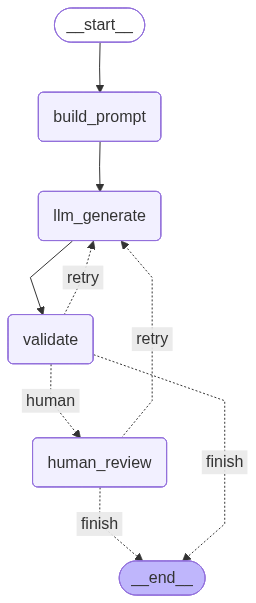

In [9]:
from IPython.display import Image, display
# Displays the graph as an image in Jupyter Notebook
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
#response = graph.invoke(initial_state,interrupt_before=human_review)

In [69]:
config = {"configurable": {"thread_id": "thread-1"}}
for event in graph.stream(initial_state, stream_mode="updates", interrupt_before="human_review", config=config):
    for node_name, output in event.items():
        print(f"Node '{node_name}' finished. Output: {output}")

Node 'build_prompt' finished. Output: {'prompt': '\n    You are a senior test engiiner you task is to generate test data.\n    Write a python data generator function to generate the test for below Schema, Constraints and Rules.\n    Data Generator function should always return python dictionary. \n    Data Generator function should return number of rcords as define in schema. \n    Generated code will be executed by python code interpreter(exec) so make sure code must be correct.\n    Schema:\n    name : string\nage : int\nemail : string\n\n    Constraints:\n    age should be less then 30 years\n\n    Rules:\n    \n\n    No external libraries.\n    Return code only.\n    '}


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-02-24T18:40:47.988998Z", "level": "info", "event": "Generatd Code:def generate_test_data():\n    \"\"\"\n    Generate one test record matching the schema:\n      - name: string\n      - age: int (must be less than 30)\n      - email: string\n\n    Returns a Python dictionary with one record.\n    \"\"\"\n    import random\n\n    first_names = ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy']\n    last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis', 'Lopez', 'Wilson']\n\n    first = random.choice(first_names)\n    last = random.choice(last_names)\n    name = f\"{first} {last}\"\n\n    # Constraint: age should be less than 30. Use a reasonable adult range 18-29.\n    age = random.randint(18, 29)\n\n    # Simple email derived from name, guaranteed to be a string\n    local_part = f\"{first}.{last}\".lower()\n    email

Node 'llm_generate' finished. Output: {'llm_output': 'def generate_test_data():\n    """\n    Generate one test record matching the schema:\n      - name: string\n      - age: int (must be less than 30)\n      - email: string\n\n    Returns a Python dictionary with one record.\n    """\n    import random\n\n    first_names = [\'Alice\', \'Bob\', \'Carol\', \'Dave\', \'Eve\', \'Frank\', \'Grace\', \'Heidi\', \'Ivan\', \'Judy\']\n    last_names = [\'Smith\', \'Johnson\', \'Williams\', \'Brown\', \'Jones\', \'Garcia\', \'Miller\', \'Davis\', \'Lopez\', \'Wilson\']\n\n    first = random.choice(first_names)\n    last = random.choice(last_names)\n    name = f"{first} {last}"\n\n    # Constraint: age should be less than 30. Use a reasonable adult range 18-29.\n    age = random.randint(18, 29)\n\n    # Simple email derived from name, guaranteed to be a string\n    local_part = f"{first}.{last}".lower()\n    email = f"{local_part}@example.com"\n\n    return {\n        "name": name,\n        "ag

In [70]:
graph.invoke({"human_decision":"approve"}, config=config)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-02-24T18:41:49.117678Z", "level": "info", "event": "Generatd Code:def generate_test_data():\n    import random\n    import string\n\n    # Helper to create a realistic-looking name\n    def _name_part(min_len=3, max_len=10):\n        length = random.randint(min_len, max_len)\n        letters = string.ascii_lowercase\n        part = ''.join(random.choice(letters) for _ in range(length))\n        return part.capitalize()\n\n    first = _name_part(3, 8)\n    last = _name_part(3, 10)\n    name = f\"{first} {last}\"\n\n    # Constraint: age should be less than 30\n    age = random.randint(0, 29)\n\n    # Build a simple email consistent with the name\n    local = f\"{first}.{last}\".lower()\n    # remove any unexpected characters (shouldn't be any, but be safe)\n    local = ''.join(ch for ch in local if ch.isalnum() or ch == '.')\n    domain_choices = [\"example.com\", \"testmail.com\", \"mail

{'schema': {'entity': 'user',
  'fields': [{'name': 'name', 'type': 'string'},
   {'name': 'age', 'type': 'int'},
   {'name': 'email', 'type': 'string'}],
  'record_count': 100},
 'constraints': ['age should be less then 30 years'],
 'rules': [],
 'locale': 'en_US',
 'framework': 'faker',
 'mode': 'M2',
 'prompt': '\n    You are a senior test engiiner you task is to generate test data.\n    Write a python data generator function to generate the test for below Schema, Constraints and Rules.\n    Data Generator function should always return python dictionary. \n    Data Generator function should return number of rcords as define in schema. \n    Generated code will be executed by python code interpreter(exec) so make sure code must be correct.\n    Schema:\n    name : string\nage : int\nemail : string\n\n    Constraints:\n    age should be less then 30 years\n\n    Rules:\n    \n\n    No external libraries.\n    Return code only.\n    ',
 'llm_output': 'def generate_test_data():\n    imp

In [16]:
namespace = {}
        #exec(code_or_data, namespace)
buffer = io.StringIO()

with contextlib.redirect_stdout(buffer):
    exec(code_or_data, namespace)

records = buffer.getvalue()
        #records = namespace["generate"](5)
logger.info(f"code Executed: {records}")

{"timestamp": "2026-02-24T17:25:03.363557Z", "level": "info", "event": "code Executed: "}


In [60]:
namespace["generate_data"]()

{'name': 'Jamie Lee', 'age': 25, 'email': 'jamie.lee31@test.org'}